# Optuna Study Analysis

Comparison of hyperparameter optimization results for the three studies in `optuna.tsv`.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated)
df_optuna = pd.read_csv("optuna.tsv", sep="\t")
df_optuna["val_bpb"] = pd.to_numeric(df_optuna["val_bpb"], errors="coerce")

df_results = pd.read_csv("results.tsv", sep="\t")
df_results["val_bpb"] = pd.to_numeric(df_results["val_bpb"], errors="coerce")
df_results["status"] = df_results["status"].str.strip().str.upper()

print(f"Total Optuna experiments: {len(df_optuna)}")
print(f"Total Results experiments: {len(df_results)}")
print(f"Optuna Study names: {df_optuna['study_name'].unique()}")
df_optuna.head(5)

Total Optuna experiments: 2653
Total Results experiments: 47
Optuna Study names: ['hyperopt_random' 'hyperopt_gp' 'hyperopt_cmaes']


,study_name,number,val_bpb,datetime_start,datetime_complete
0,hyperopt_random,0,0.487860,2026-03-23 19:01:34.261457,2026-03-23 19:17:04.921851
1,hyperopt_gp,0,0.486935,2026-03-24 11:01:14.924271,2026-03-24 11:08:38.881651
2,hyperopt_cmaes,0,0.487850,2026-03-24 19:03:51.894693,2026-03-24 19:11:13.828871
3,hyperopt_random,1,0.485370,2026-03-23 19:17:05.154247,2026-03-23 19:26:40.254847
4,hyperopt_gp,1,0.486465,2026-03-24 11:08:39.106804,2026-03-24 11:15:31.318155


## Val BPB Over Time

Track how the best (kept) val_bpb evolves for each study as experiments progress.

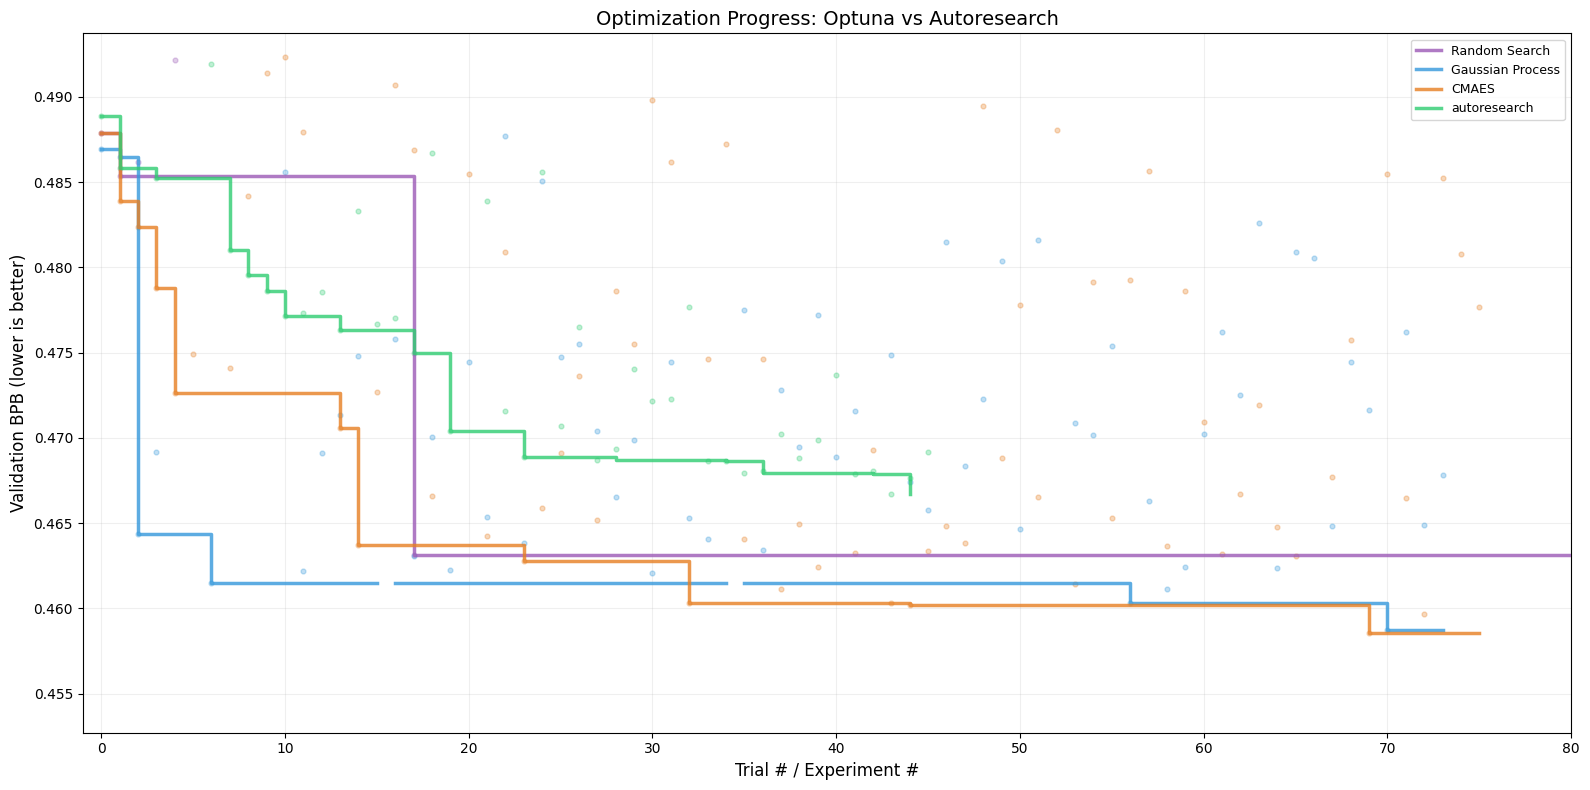

Saved to progress.png


In [17]:
fig, ax = plt.subplots(figsize=(16, 8))

colors = {
    "hyperopt_random": "#9b59b6",
    "hyperopt_gp": "#3498db",
    "hyperopt_cmaes": "#e67e22",
    "autoresearch": "#2ecc71"
}
display_names = {
    "hyperopt_random": "Random Search",
    "hyperopt_gp": "Gaussian Process",
    "hyperopt_cmaes": "CMAES",
}

all_best_values = []

# 1. Plot Optuna Studies
for study_name in df_optuna["study_name"].unique():
    study_df = df_optuna[df_optuna["study_name"] == study_name].copy()
    study_df = study_df.sort_values("number").reset_index(drop=True)
    
    # Calculate running minimum
    study_df["running_min"] = study_df["val_bpb"].cummin()
    
    color = colors.get(study_name, None)
    
    # Plot raw points as faint dots
    ax.scatter(study_df["number"], study_df["val_bpb"], 
               c=color, s=12, alpha=0.3, zorder=2)
    
    # Plot running minimum step line
    ax.step(study_df["number"], study_df["running_min"], where="post", 
            color=color, linewidth=2.5, alpha=0.8, zorder=3, label=display_names[study_name])
    
    all_best_values.append(study_df["running_min"].min())

# 2. Plot Autoresearch (results.tsv)
# Filter out crashes
valid_results = df_results[df_results["status"] != "CRASH"].copy().reset_index()
# Plot all as faint dots
ax.scatter(valid_results.index, valid_results["val_bpb"], 
           c=colors["autoresearch"], s=12, alpha=0.3, zorder=2)

# Calculate running minimum for KEEP experiments
kept_results = df_results[df_results["status"] == "KEEP"].copy().reset_index()
kept_results["running_min"] = kept_results["val_bpb"].cummin()
ax.step(kept_results["index"], kept_results["running_min"], where="post", 
        color=colors["autoresearch"], linewidth=2.5, alpha=0.8, zorder=3, label="autoresearch")

all_best_values.append(kept_results["running_min"].min())

baseline_val = df_optuna.loc[0, "val_bpb"]
best_val = min(all_best_values)

ax.set_xlabel("Trial # / Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title("Optimization Progress: Optuna vs Autoresearch", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: limit the view to the interesting region around best results and baseline
margin = (baseline_val - best_val) * 0.2
ax.set_ylim(best_val - margin, baseline_val + margin)
ax.set_xlim(-1, 80)

plt.tight_layout()
plt.savefig("progress.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved to progress.png")

## Best Results per Study

In [12]:
for study_name in df_optuna["study_name"].unique():
    study_df = df_optuna[df_optuna["study_name"] == study_name]
    best_row = study_df.loc[study_df["val_bpb"].idxmin()]
    print(f"Study: {study_name}")
    print(f"  Best trial #{int(best_row['number'])}: {best_row['val_bpb']:.6f}")
    print()

kept_results = df_results[df_results["status"] == "KEEP"]
best_res_row = kept_results.loc[kept_results["val_bpb"].idxmin()]
print(f"Study: autoresearch (results.tsv)")
print(f"  Best experiment #{best_res_row.name}: {best_res_row['val_bpb']:.6f}")


Study: hyperopt_random
  Best trial #17: 0.463107

Study: hyperopt_gp
  Best trial #70: 0.458733

Study: hyperopt_cmaes
  Best trial #69: 0.458569

Study: autoresearch (results.tsv)
  Best experiment #44: 0.466704
